<a href="https://colab.research.google.com/github/kashish1720/mldl_lab_sem6/blob/main/miniproject/Brain_Tumor_VGG16_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Brain Tumor MRI Classification using VGG16 Transfer Learning

**Dataset:** Kaggle Brain Tumor MRI Dataset (7023 images, 4 classes)

**Classes:** glioma | meningioma | notumor | pituitary

## ✅ STEP 0 — Check GPU

In [ ]:
import tensorflow as tf
print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# If GPU list is empty → Runtime > Change runtime type > T4 GPU

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## ✅ STEP 1 — Install & Import All Libraries

In [ ]:
# All standard Colab libraries — no extra installs needed
import os
import zipfile
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## ✅ STEP 2 — Upload & Extract Dataset

> **How to get the dataset:**
> 1. Go to: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
> 2. Download the ZIP file
> 3. Run the cell below — it will prompt you to upload the ZIP

In [ ]:
from google.colab import files

print('📁 Please upload your Kaggle dataset ZIP file...')
uploaded = files.upload()

# Get the uploaded filename automatically
zip_filename = list(uploaded.keys())[0]
print(f'✅ Uploaded: {zip_filename}')

📁 Please upload your Kaggle dataset ZIP file...


Saving archive.zip to archive.zip
✅ Uploaded: archive.zip


In [ ]:
# Extract the ZIP
EXTRACT_PATH = '/content/brain_tumor_dataset'

if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)
os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(EXTRACT_PATH)

print('✅ Extraction done!')

# Show extracted structure
for root, dirs, files_list in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files_list[:3]:
            print(f'{indent}  {f}')

✅ Extraction done!
brain_tumor_dataset/
  Training/
    pituitary/
    meningioma/
    glioma/
    notumor/
  Testing/
    pituitary/
    meningioma/
    glioma/
    notumor/


In [ ]:
# ─── AUTO-DETECT dataset folder structure ───
# The Kaggle zip may have: Training/ and Testing/ folders directly,
# or they might be nested one level deeper.

def find_folder(base, name):
    """Recursively find a folder by name."""
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            if d.lower() == name.lower():
                return os.path.join(root, d)
    return None

TRAIN_DIR = find_folder(EXTRACT_PATH, 'Training')
TEST_DIR  = find_folder(EXTRACT_PATH, 'Testing')

print(f'Training folder : {TRAIN_DIR}')
print(f'Testing folder  : {TEST_DIR}')

assert TRAIN_DIR and os.path.exists(TRAIN_DIR), '❌ Training folder not found!'
assert TEST_DIR  and os.path.exists(TEST_DIR),  '❌ Testing folder not found!'

# List classes
CLASSES = sorted(os.listdir(TRAIN_DIR))
CLASSES = [c for c in CLASSES if os.path.isdir(os.path.join(TRAIN_DIR, c))]
print(f'\n✅ Classes found: {CLASSES}')
print(f'Number of classes: {len(CLASSES)}')

# Count images per class
print('\n📊 Image counts:')
for cls in CLASSES:
    train_count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    test_count  = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f'  {cls:15s} → Train: {train_count:4d} | Test: {test_count:4d}')

Training folder : /content/brain_tumor_dataset/Training
Testing folder  : /content/brain_tumor_dataset/Testing

✅ Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4

📊 Image counts:
  glioma          → Train: 1400 | Test:  400
  meningioma      → Train: 1400 | Test:  400
  notumor         → Train: 1400 | Test:  400
  pituitary       → Train: 1400 | Test:  400


## ✅ STEP 3 — Create Validation Split & Data Generators

In [ ]:
# ─── Constants ───
IMG_SIZE    = (224, 224)   # VGG16 input size
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = len(CLASSES)

# ─── Training Generator (with augmentation) ───
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 15,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    horizontal_flip   = True,
    zoom_range        = 0.1,
    shear_range       = 0.1,
    validation_split  = 0.2    # 20% of training data → validation
)

# ─── Test / Validation Generator (NO augmentation) ───
test_datagen = ImageDataGenerator(rescale=1./255)

# ─── Create generators ───
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED,
    shuffle      = True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED,
    shuffle      = False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False
)

print(f'\n✅ Generators created!')
print(f'   Train samples     : {train_generator.samples}')
print(f'   Validation samples: {val_generator.samples}')
print(f'   Test samples      : {test_generator.samples}')
print(f'   Class indices     : {train_generator.class_indices}')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

✅ Generators created!
   Train samples     : 4480
   Validation samples: 1120
   Test samples      : 1600
   Class indices     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


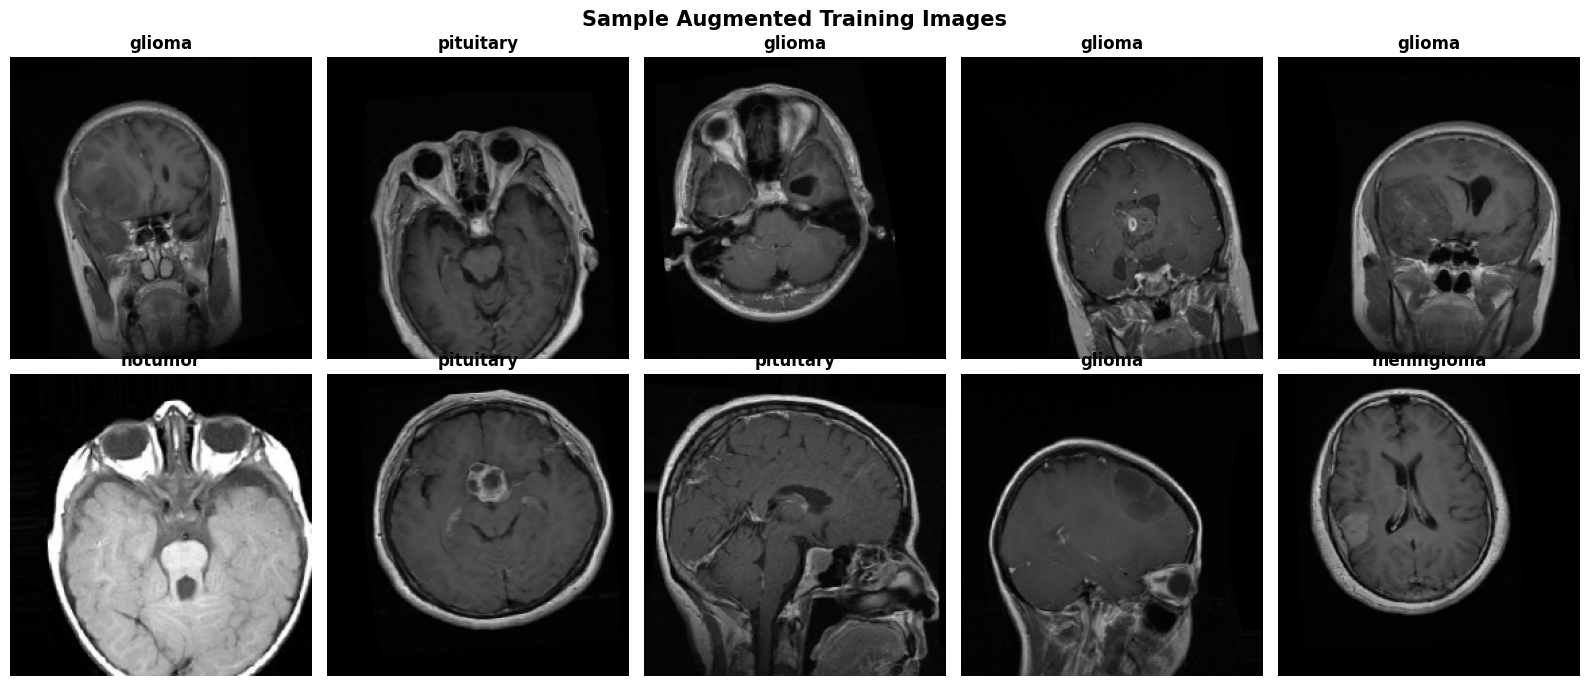

In [ ]:
# ─── Visualize sample training images ───
sample_batch_images, sample_batch_labels = next(train_generator)

label_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch_images[i])
    label_idx = np.argmax(sample_batch_labels[i])
    ax.set_title(label_names[label_idx], fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## ✅ STEP 4 — Build VGG16 Transfer Learning Model

In [ ]:
# ─── Load VGG16 base (ImageNet weights, no top classifier) ───
base_model = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

# ─── Freeze all base layers ───
base_model.trainable = False

print(f'VGG16 base layers  : {len(base_model.layers)}')
print(f'Trainable params   : {base_model.count_params():,}')

# ─── Add custom classification head ───
x = base_model.output
x = GlobalAveragePooling2D()(x)          # Better than Flatten for transfer learning
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ─── Compile ───
model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('\n✅ Model built and compiled!')
print(f'Total params     : {model.count_params():,}')
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Trainable params : {trainable:,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base layers  : 19
Trainable params   : 14,714,688

✅ Model built and compiled!
Total params     : 15,109,700
Trainable params : 395,012


In [ ]:
# Optional — view full model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## ✅ STEP 5 — Train the Model

In [ ]:
# ─── Callbacks ───
callbacks = [
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    ModelCheckpoint(
        filepath             = '/content/best_model.keras',
        monitor              = 'val_accuracy',
        save_best_only       = True,
        verbose              = 1
    )
]

# ─── Train Phase 1: Only custom head layers (base frozen) ───
print('🚀 Starting Phase 1 Training (frozen base)...')
history = model.fit(
    train_generator,
    epochs              = 20,
    validation_data     = val_generator,
    callbacks           = callbacks,
    verbose             = 1
)

print('\n✅ Phase 1 Training complete!')

🚀 Starting Phase 1 Training (frozen base)...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.2779 - loss: 1.4745
Epoch 1: val_accuracy improved from None to 0.62143, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 569ms/step - accuracy: 0.3404 - loss: 1.3717 - val_accuracy: 0.6214 - val_loss: 1.1512 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.4912 - loss: 1.1530
Epoch 2: val_accuracy improved from 0.62143 to 0.70714, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 562ms/step - accuracy: 0.5379 - loss: 1.0858 - val_accuracy: 0.7071 - val_loss: 0.8652 - learning_rate: 1.0000e-04
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6543 - loss: 0.9124
Epoch 3: val_accuracy improved from 0.70714 to 0.76071, saving model to /content

In [ ]:
# ─── Phase 2: Fine-tuning — Unfreeze last 4 VGG16 layers ───
print('🔓 Unfreezing last 4 layers of VGG16 for fine-tuning...')

for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 4,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = '/content/best_model_finetuned.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    )
]

print('🚀 Starting Phase 2 Fine-tuning...')
history_ft = model.fit(
    train_generator,
    epochs          = 10,
    validation_data = val_generator,
    callbacks       = callbacks_ft,
    verbose         = 1
)

print('\n✅ Phase 2 Fine-tuning complete!')

🔓 Unfreezing last 4 layers of VGG16 for fine-tuning...
🚀 Starting Phase 2 Fine-tuning...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8543 - loss: 0.3974
Epoch 1: val_accuracy improved from None to 0.89018, saving model to /content/best_model_finetuned.keras

Epoch 1: finished saving model to /content/best_model_finetuned.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 91s 593ms/step - accuracy: 0.8629 - loss: 0.3773 - val_accuracy: 0.8902 - val_loss: 0.3057
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8788 - loss: 0.3297
Epoch 2: val_accuracy improved from 0.89018 to 0.89554, saving model to /content/best_model_finetuned.keras

Epoch 2: finished saving model to /content/best_model_finetuned.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 584ms/step - accuracy: 0.8857 - loss: 0.3159 - val_accuracy: 0.8955 - val_loss: 0.2889
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9079 - loss: 0.2692
Epoch 3: val_accuracy improved from 0.89554 to 0.896

## ✅ STEP 6 — Plot Training History

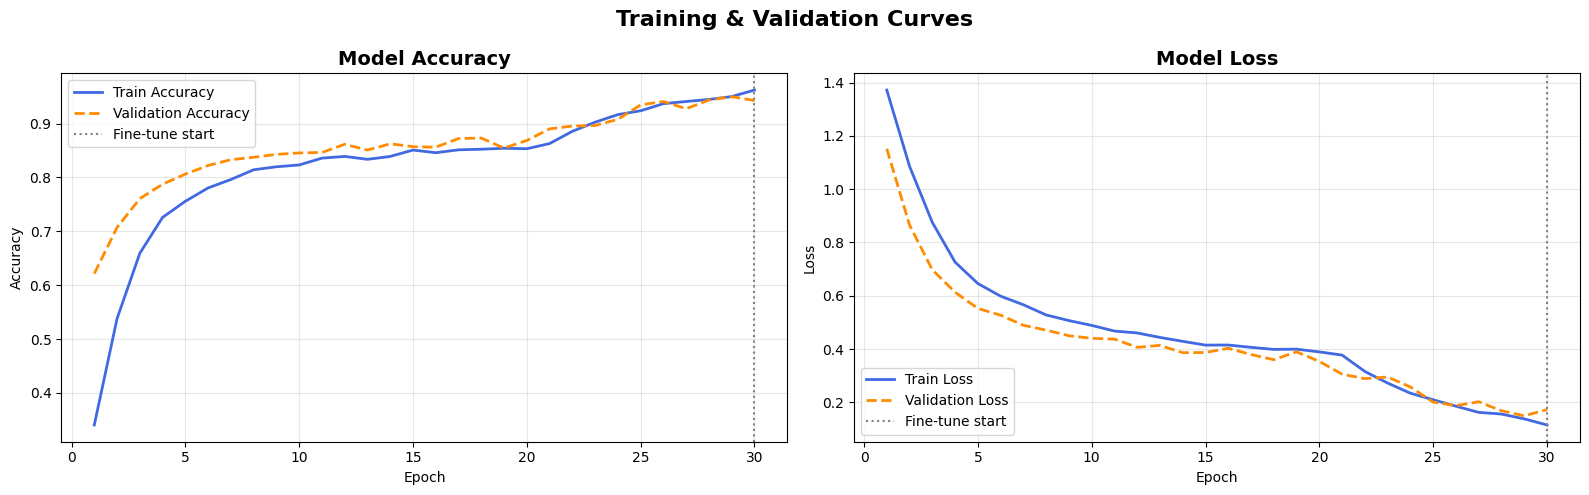

In [ ]:
def plot_history(h1, h2=None):
    """Plot accuracy and loss curves, combining Phase 1 and Phase 2."""
    acc  = h1.history['accuracy']
    val_acc  = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    if h2:
        acc      += h2.history['accuracy']
        val_acc  += h2.history['val_accuracy']
        loss     += h2.history['loss']
        val_loss += h2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy
    axes[0].plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue',  linewidth=2)
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
    if h2:
        axes[0].axvline(x=len(h1.history['accuracy']), color='gray', linestyle=':', label='Fine-tune start')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_range, loss,     label='Train Loss',      color='royalblue',  linewidth=2)
    axes[1].plot(epochs_range, val_loss, label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
    if h2:
        axes[1].axvline(x=len(h1.history['loss']), color='gray', linestyle=':', label='Fine-tune start')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training & Validation Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history, history_ft)

## ✅ STEP 7 — Evaluate on Test Set

In [ ]:
# Load the best saved model
best_model_path = '/content/best_model_finetuned.keras'
if not os.path.exists(best_model_path):
    best_model_path = '/content/best_model.keras'

model = tf.keras.models.load_model(best_model_path)
print(f'✅ Loaded best model from: {best_model_path}')

# Reset test generator before evaluation (important!)
test_generator.reset()

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f'\n🎯 Test Loss    : {test_loss:.4f}')
print(f'🎯 Test Accuracy: {test_accuracy * 100:.2f}%')

✅ Loaded best model from: /content/best_model_finetuned.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.8919 - loss: 0.4459

🎯 Test Loss    : 0.4459
🎯 Test Accuracy: 89.19%


In [ ]:
# ─── Predictions for confusion matrix & report ───
test_generator.reset()   # Always reset before predict!

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

class_names  = list(test_generator.class_indices.keys())

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 221ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.71      0.83       400
  meningioma       0.83      0.86      0.85       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.87      0.99      0.93       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



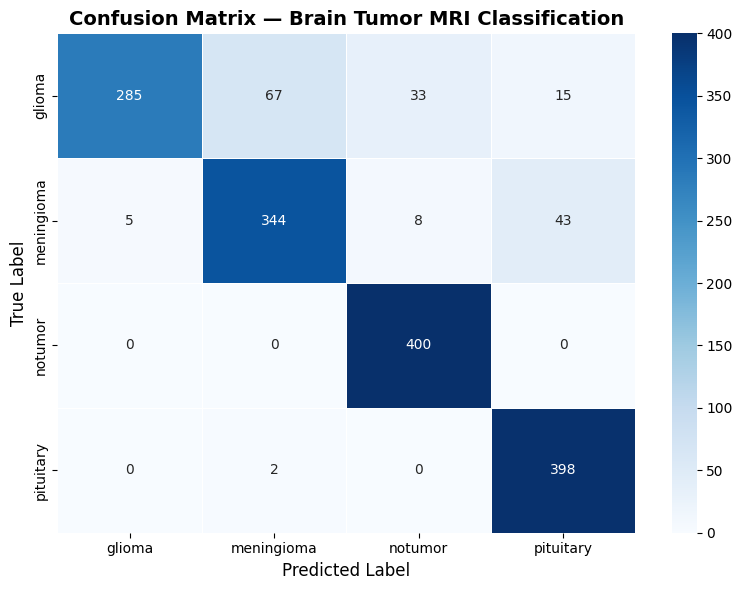

In [ ]:
# ─── Confusion Matrix ───
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= class_names,
    yticklabels= class_names,
    linewidths = 0.5
)
plt.title('Confusion Matrix — Brain Tumor MRI Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ STEP 8 — Visualize Sample Predictions

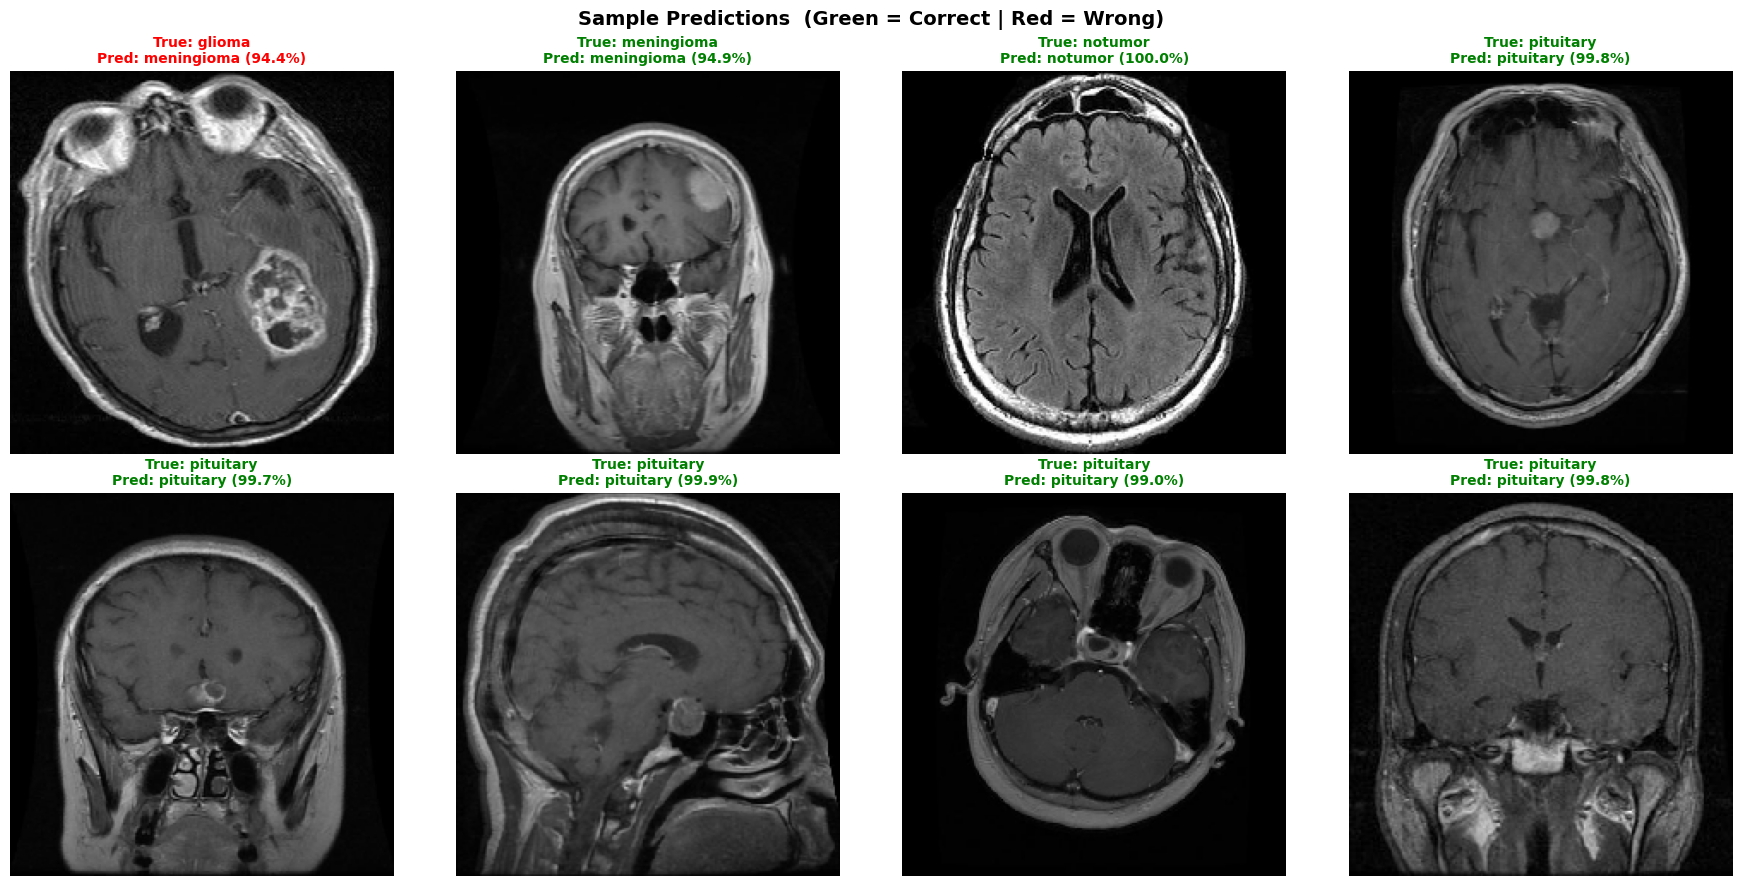

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_and_show(img_path, model, class_names, img_size=(224, 224)):
    """Load one image, predict, and return result."""
    img = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100
    return img, pred_class, confidence

# Pick 8 random test images
test_images = []
test_labels = []

for cls in class_names:
    cls_path = os.path.join(TEST_DIR, cls)
    imgs = os.listdir(cls_path)
    if imgs:
        chosen = random.choice(imgs)
        test_images.append(os.path.join(cls_path, chosen))
        test_labels.append(cls)

# Add a few more random ones
all_test_paths = []
for cls in class_names:
    cls_path = os.path.join(TEST_DIR, cls)
    for f in os.listdir(cls_path):
        all_test_paths.append((os.path.join(cls_path, f), cls))

random.shuffle(all_test_paths)
extra = all_test_paths[:4]
for p, l in extra:
    test_images.append(p)
    test_labels.append(l)

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, ax in enumerate(axes.flatten()):
    if i >= len(test_images):
        ax.axis('off')
        continue
    img, pred_class, conf = predict_and_show(test_images[i], model, class_names)
    true_class = test_labels[i]
    color = 'green' if pred_class == true_class else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true_class}\nPred: {pred_class} ({conf:.1f}%)',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Predictions  (Green = Correct | Red = Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ STEP 9 — Save & Download Model

In [ ]:
# Save final model
model.save('/content/brain_tumor_vgg16_final.keras')
print('✅ Model saved!')

# Download (optional)
# from google.colab import files
# files.download('/content/brain_tumor_vgg16_final.keras')
# files.download('/content/confusion_matrix.png')
# files.download('/content/training_curves.png')

✅ Model saved!


## ✅ STEP 10 — Final Summary

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

acc_score = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred, average='weighted')

print('=' * 50)
print('      FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Test Accuracy  : {acc_score * 100:.2f}%')
print(f'  Weighted F1    : {f1:.4f}')
print(f'  Test Loss      : {test_loss:.4f}')
print('=' * 50)
print('  Model  : VGG16 + GlobalAvgPool + Dense(512) + Dense(256)')
print('  Classes: glioma | meningioma | notumor | pituitary')
print('  Input  : 224x224 RGB')
print('  Loss   : Categorical Cross-Entropy')
print('=' * 50)

      FINAL MODEL PERFORMANCE SUMMARY
  Test Accuracy  : 89.19%
  Weighted F1    : 0.8884
  Test Loss      : 0.4459
  Model  : VGG16 + GlobalAvgPool + Dense(512) + Dense(256)
  Classes: glioma | meningioma | notumor | pituitary
  Input  : 224x224 RGB
  Loss   : Categorical Cross-Entropy


---
## Key Terms

| Term | One-line Explanation |
|------|---------------------|
| **Transfer Learning** | Using ImageNet-pretrained VGG16 weights instead of training from scratch |
| **Frozen Layers** | Base model weights kept fixed so only the new head learns |
| **Fine-tuning** | Unfreezing last few layers for domain-specific adjustment |
| **GlobalAveragePooling2D** | Reduces feature maps to a single vector — less overfitting than Flatten |
| **Data Augmentation** | Rotation, flip, zoom to artificially increase training diversity |
| **Dropout** | Randomly zeroes neurons during training to prevent overfitting |
| **Softmax** | Converts raw scores to probabilities that sum to 1 |
| **Categorical Cross-Entropy** | Loss function for multi-class problems |
| **EarlyStopping** | Stops training when val_accuracy stops improving |
| **Grad-CAM** | Visualizes which part of the image influenced the prediction (future scope) |